In [1]:
import os
import time
import numpy as np
import uproot
import matplotlib.pyplot as plt
import ROOT
from ROOT import RooFit as RF
from ROOT import (
    kBlue, kRed, kViolet, kMagenta, kOrange, kGreen, kBlack,
    kAzure, kFullCircle, kDashed, kDotted, kDashDotted
)
from IPython.display import Image as IPyImage, display as ipydisplay

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

ROOT.gROOT.SetBatch(True)
ROOT.EnableImplicitMT()

# Custom HILL/HORNS PDFs, compiled standalone against this ROOT build.
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))

Welcome to JupyROOT 6.30/02
Custom PDFs: True True



In [2]:
# tree location inside each ROOT file
TREE_PATH = "Tuple/DecayTree"
# input files
# Input files
DPI_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_down_final_block7.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_up_final_block8.root",
]
DK_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

# sanity check: ensure all input files exist
assert all(os.path.exists(f) for f in DPI_FILES + DK_FILES), "Missing input ROOT files."

In [3]:
# histogram settings (Bd mass)
NBINS = 300
mmin, mmax = 4950.0, 6000.0  # MeV

In [4]:
# D mass / window (applies to both channels)
D_MASS   = 1869.65  # MeV
D_WINDOW = 20.0     # MeV

# common vertex-quality cuts
B_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5
D_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5

# bachelor PIDK thresholds (the only difference between channels)
BACHELOR_PIDK_MAX = 0 # Dπ requires PIDK < 0  (pion-like)
BACHELOR_PIDK_MIN = 5 # DK requires  PIDK > 5  (kaon-like)

# common flight/IP/pointing & MVA cuts
B_FDCHI2_MIN = 70.0 # WAS 100.0, 70
B_IPCHI2_MAX = 15.0 # WAS 15.0 , 8.0
B_DIRA_MIN   = 0.9995
MVA_BRANCH   = "lab0_MVA"
MVA_CUT      = 0.9 #0.972

# branches we actually read
COMMON_BRANCHES = [
    "lab0_MASS",              # Bd mass (for histogram)
    "lab0_END_VCHI2DOF",      # B vertex chi2/dof
    "lab2_END_VCHI2DOF",      # D vertex chi2/dof
    "lab2_MASS",              # D mass (for window)
    "lab1_PIDK",              # bachelor PIDK
    "lab0_BPVFDCHI2",         # B flight-distance chi2
    "lab0_BPVIPCHI2",         # B impact-parameter chi2
    "lab0_BPVDIRA",           # B pointing angle cosine
    MVA_BRANCH,               # MVA score
]

In [5]:
# helper to build Bd mass arrays for a given mode (Dpi or DK)
def build_vals(files, mode="Dpi"):
    """
    Build selected Bd mass values for the requested mode.
    Parameters
    ----------
    files : list[str]
        Input ROOT file paths.
    mode : {"Dpi","DK"}
        Channel key. The ONLY difference is bachelor PIDK:
          - Dpi: lab1_PIDK <  BACHELOR_PIDK_MAX
          - DK : lab1_PIDK >  BACHELOR_PIDK_MIN
    Returns
    -------
    np.ndarray
        1D array of Bd mass values passing all selections and within [mmin, mmax].
    """
    assert mode in ("Dpi", "DK")
    vals_all = []

    print(f"\n[build {mode}] applying common Bd selection + PID_{mode}...")
    # iterate in chunks to keep memory bounded
    for arrays in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=COMMON_BRANCHES,
                       step_size="60 MB",
                       library="np", allow_missing=False),
        desc=f"Reading {mode} tuples"
    ):
        mB     = arrays["lab0_MASS"]
        bchi   = arrays["lab0_END_VCHI2DOF"]
        dchi   = arrays["lab2_END_VCHI2DOF"]
        mD     = arrays["lab2_MASS"]
        pidk   = arrays["lab1_PIDK"]
        fdchi2 = arrays["lab0_BPVFDCHI2"]
        ipchi2 = arrays["lab0_BPVIPCHI2"]
        dira   = arrays["lab0_BPVDIRA"]
        mva    = arrays[MVA_BRANCH]

        # require finite entries in all used branches
        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva)
        )

        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )
        # common selection for BOTH Dπ and DK
        base_sel = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )
        # only difference: PID on the bachelor
        pid_sel = (pidk < BACHELOR_PIDK_MAX) if mode == "Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base_sel & pid_sel
        if np.any(sel):
            vals_all.append(mB[sel])
    # concatenate and keep in histogram range
    vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
    vals = vals[(vals > mmin) & (vals < mmax)]
    print(f"[build {mode}] kept {vals.size} events")
    if vals.size == 0:
        raise RuntimeError(f"No {mode} events after cuts.")
    return vals

In [9]:
# build Bd mass arrays for both channels
vals_Dpi = build_vals(DPI_FILES, mode="Dpi")
vals_DK  = build_vals(DK_FILES,  mode="DK")
# book histograms
h_Dpi = ROOT.TH1D("h_Dpi", "Bd#rightarrowD#pi; m(B) [MeV]; Events / bin", NBINS, mmin, mmax)
h_DK  = ROOT.TH1D("h_DK",  "Bd#rightarrowDK; m(B) [MeV]; Events / bin",   NBINS, mmin, mmax)
# fill (loop is fine and explicit; ROOT hist fill is C++ fast)
for x in vals_Dpi:
    h_Dpi.Fill(float(x))
for x in vals_DK:
    h_DK.Fill(float(x))
# write to file
out_name = "Bd2Dpi_DK_hists.root"
fout = ROOT.TFile.Open(out_name, "RECREATE")
h_Dpi.Write()
h_DK.Write()
fout.Close()
print(f"Saved histograms to {out_name}")


[build Dpi] applying common Bd selection + PID_Dpi...



Reading Dpi tuples: 0it [00:00, ?it/s]


Reading Dpi tuples: 3it [00:02,  1.49it/s]



[build Dpi] kept 1975718 events

[build DK] applying common Bd selection + PID_DK...



Reading DK tuples: 2it [00:00,  2.93it/s]



[build DK] kept 264679 events
Saved histograms to Bd2Dpi_DK_hists.root



In [10]:
def seed_slope_from_hist(hist, lo, hi):
    nb = hist.GetNbinsX()
    x, y = [], []
    for i in range(1, nb+1):
        xc = hist.GetBinCenter(i)
        if lo <= xc <= hi:
            x.append(xc)
            y.append(hist.GetBinContent(i))
    x = np.array(x); y = np.array(y)
    if len(x) > 2:
        return np.polyfit(x, y, 1)[0]
    return 0.0

coef_Dpi = seed_slope_from_hist(h_Dpi, 4950, 5150)
coef_DK  = seed_slope_from_hist(h_DK,  4950, 5150)

# Seed μ, σ from both histograms
vals_all = []
for hist in (h_Dpi, h_DK):
    for i in range(1, hist.GetNbinsX()+1):
        xbin = hist.GetBinCenter(i)
        n = int(hist.GetBinContent(i))
        if n > 0:
            vals_all.extend([xbin]*n)
vals_all = np.array(vals_all, dtype=float)

focus = vals_all[(vals_all > 5200) & (vals_all < 5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200, 5350))
    edges = np.linspace(5200, 5350, 81)
    xmid  = 0.5*(edges[1:] + edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals_all[(vals_all > mu0-40) & (vals_all < mu0+40)]
sig0 = np.std(selp) if selp.size > 1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

print(f"Seed mu0 ~ {mu0:.1f}, sig0 ~ {sig0:.1f}")

Seed mu0 ~ 5281.6, sig0 ~ 16.9



In [12]:
print(f"[config] Using NBINS={NBINS}, mmin={mmin}, mmax={mmax} from Cell 1")
f = ROOT.TFile.Open("Bd2Dpi_DK_hists.root")
assert f and not f.IsZombie(), "Could not open Bd2Dpi_DK_hists.root"
h_Dpi = f.Get("h_Dpi")
h_DK  = f.Get("h_DK")
assert h_Dpi and h_DK, "Could not retrieve h_Dpi or h_DK from file."

# Check consistency with Cell 1 binning
assert h_Dpi.GetNbinsX() == NBINS and h_DK.GetNbinsX() == NBINS, \
    "Histogram NBINS mismatch w.r.t. Cell 1"

xmin_Dpi = h_Dpi.GetXaxis().GetXmin()
xmax_Dpi = h_Dpi.GetXaxis().GetXmax()
xmin_DK  = h_DK.GetXaxis().GetXmin()
xmax_DK  = h_DK.GetXaxis().GetXmax()

assert abs(xmin_Dpi - mmin) < 1e-3 and abs(xmax_Dpi - mmax) < 1e-3, \
    "Dpi hist mass range mismatch w.r.t. Cell 1"
assert abs(xmin_DK  - mmin) < 1e-3 and abs(xmax_DK  - mmax) < 1e-3, \
    "DK hist mass range mismatch w.r.t. Cell 1"

Ntot_Dpi = float(h_Dpi.Integral())
Ntot_DK  = float(h_DK.Integral())
print(f"Ntot_Dpi = {Ntot_Dpi:.0f}, Ntot_DK = {Ntot_DK:.0f}")

m = ROOT.RooRealVar("m", "m(B) [MeV/c^{2}]", mmin, mmax)
dh_Dpi = ROOT.RooDataHist("dh_Dpi", "Dpi binned", ROOT.RooArgList(m), h_Dpi)
dh_DK  = ROOT.RooDataHist("dh_DK",  "DK binned",  ROOT.RooArgList(m), h_DK)

[config] Using NBINS=300, mmin=4950.0, mmax=6000.0 from Cell 1
Ntot_Dpi = 1975718, Ntot_DK = 264679



In [ ]:
coef_Dpi = seed_slope_from_hist(h_Dpi, 4950, 5150)
coef_DK  = seed_slope_from_hist(h_DK,  4950, 5150)

# Seed μ, σ from both histograms
vals_all = []
for hist in (h_Dpi, h_DK):
    for i in range(1, hist.GetNbinsX()+1):
        xbin = hist.GetBinCenter(i)
        n = int(hist.GetBinContent(i))
        if n > 0:
            vals_all.extend([xbin]*n)
vals_all = np.array(vals_all, dtype=float)

focus = vals_all[(vals_all > 5200) & (vals_all < 5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200, 5350))
    edges = np.linspace(5200, 5350, 81)
    xmid  = 0.5*(edges[1:] + edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals_all[(vals_all > mu0-40) & (vals_all < mu0+40)]
sig0 = np.std(selp) if selp.size > 1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

print(f"Seed mu0 ~ {mu0:.1f}, sig0 ~ {sig0:.1f}")

Seed mu0 ~ 5281.6, sig0 ~ 16.9



In [15]:
#Builds DK model (signal DSCB, Dπ→DK misID DSCB, HILL/HORNS, exponential comb).
#Fits to dh_DK; stores fitted values and background-shape params.

print("\n[fit DK] building DK-only model...")

mu_DK_fit  = ROOT.RooRealVar("mu_DK_fit","mu_DK_fit",  mu0,  mu0-30., mu0+30.)
sig_DK_fit = ROOT.RooRealVar("sig_DK_fit","sig_DK_fit",sig0, 8., 30.)

aL_DK_fit  = ROOT.RooRealVar("aL_DK_fit",  "aL_DK_fit",  1.6, 0.5, 5.0)
nL_DK_fit  = ROOT.RooRealVar("nL_DK_fit",  "nL_DK_fit",  4.0, 1.0, 20.0)
aR_DK_fit  = ROOT.RooRealVar("aR_DK_fit",  "aR_DK_fit", -2.0, -6.0, -0.5)
nR_DK_fit  = ROOT.RooRealVar("nR_DK_fit",  "nR_DK_fit",  3.0, 1.0, 20.0)
fLR_DK_fit = ROOT.RooRealVar("fLR_DK_fit","fLR_DK_fit",0.5, 0.1, 0.9)

sigL_DK_fit = ROOT.RooCBShape("sigL_DK_fit","left CB DK fit",
                              m, mu_DK_fit, sig_DK_fit, aL_DK_fit, nL_DK_fit)
sigR_DK_fit = ROOT.RooCBShape("sigR_DK_fit","right CB DK fit",
                              m, mu_DK_fit, sig_DK_fit, aR_DK_fit, nR_DK_fit)
SIG_DK_fit  = ROOT.RooAddPdf("SIG_DK_fit","DSCB DK fit",
                             ROOT.RooArgList(sigL_DK_fit, sigR_DK_fit),
                             ROOT.RooArgList(fLR_DK_fit))

# Mis-ID Dπ -> DK (DSCB)
dMis_DK_fit   = ROOT.RooRealVar("dMis_DK_fit","Dpi->DK shift fit",50.0,30.0,80.0)
mu_mis_DK_fit = ROOT.RooFormulaVar("mu_mis_DK_fit","@0+@1",
                                   ROOT.RooArgList(mu_DK_fit,dMis_DK_fit))
sig_mis_DK_fit= ROOT.RooRealVar("sig_mis_DK_fit","misID width DK fit",
                                1.4*sig0, sig0, 3.0*sig0)

aL_mis_fit = ROOT.RooRealVar("aL_mis_fit","aL_mis_fit",1.5,0.5,5.0)
nL_mis_fit = ROOT.RooRealVar("nL_mis_fit","nL_mis_fit",3.0,1.0,20.0)
MIS_L_fit  = ROOT.RooCBShape("MIS_L_fit","misID left CB fit",
                             m, mu_mis_DK_fit, sig_mis_DK_fit, aL_mis_fit, nL_mis_fit)

aR_mis_fit = ROOT.RooRealVar("aR_mis_fit","aR_mis_fit",-1.5,-8.0,-0.2)
nR_mis_fit = ROOT.RooRealVar("nR_mis_fit","nR_mis_fit",3.0,1.0,20.0)
MIS_R_fit  = ROOT.RooCBShape("MIS_R_fit","misID right CB fit",
                             m, mu_mis_DK_fit, sig_mis_DK_fit, aR_mis_fit, nR_mis_fit)

fLR_mis_fit = ROOT.RooRealVar("fLR_mis_fit","frac left misID fit",0.5,0.1,0.9)
MIS_DK_fit  = ROOT.RooAddPdf("MIS_DK_fit","misID Dpi->DK fit",
                             ROOT.RooArgList(MIS_L_fit, MIS_R_fit),
                             ROOT.RooArgList(fLR_mis_fit))

# Partial-reco HILL/HORNS
h_a_DK_fit  = ROOT.RooRealVar("h_a_DK_fit","HILL a DK fit",5000,4920,5080)
#h_a_DK_fit   = ROOT.RooRealVar("h_a_DK_fit","HILL a DK fit",max(5000., mmin+30.), mmin+30., 5070.)
h_b_DK_fit  = ROOT.RooRealVar("h_b_DK_fit","HILL b DK fit",float(hb_seed),5050,5200)
h_c_DK_fit  = ROOT.RooRealVar("h_csi_DK_fit","HILL csi DK fit",0.45,0,1)
h_sh_DK_fit = ROOT.RooRealVar("h_shift_DK_fit","HILL shift DK fit",0.0,-30.,30.)
h_sg_DK_fit = ROOT.RooRealVar("h_sigma_DK_fit","HILL sigma DK fit",22,12,45)
h_rs_DK_fit = ROOT.RooRealVar("h_rs_DK_fit","HILL ratio_sigma DK fit",2.0,1.1,3.5)
h_fs_DK_fit = ROOT.RooRealVar("h_fs_DK_fit","HILL fraction_sigma DK fit",0.5,0.2,0.8)
BKG_g_DK_fit = ROOT.RooHILLdini("BKG_g_DK_fit","gamma-like DK fit",
                                m,h_a_DK_fit,h_b_DK_fit,h_c_DK_fit,
                                h_sh_DK_fit,h_sg_DK_fit,h_rs_DK_fit,h_fs_DK_fit)

r_a_DK_fit  = ROOT.RooRealVar("r_a_DK_fit","HORNS a DK fit",5050,4970,5150)
r_b_DK_fit  = ROOT.RooRealVar("r_b_DK_fit","HORNS b DK fit",float(rb_seed),5100,5250)
r_c_DK_fit  = ROOT.RooRealVar("r_csi_DK_fit","HORNS csi DK fit",0.30,0,1)
r_sh_DK_fit = ROOT.RooRealVar("r_sh_DK_fit","HORNS shift DK fit",0.0,-30.,30.)
r_sg_DK_fit = ROOT.RooRealVar("r_sigma_DK_fit","HORNS sigma DK fit",24,12,50)
r_rs_DK_fit = ROOT.RooRealVar("r_rs_DK_fit","HORNS ratio_sigma DK fit",2.0,1.1,3.5)
r_fs_DK_fit = ROOT.RooRealVar("r_fs_DK_fit","HORNS fraction_sigma DK fit",0.5,0.2,0.8)
BKG_pi_DK_fit = ROOT.RooHORNSdini("BKG_pi_DK_fit","pi0-like DK fit",
                                  m,r_a_DK_fit,r_b_DK_fit,r_c_DK_fit,
                                  r_sh_DK_fit,r_sg_DK_fit,r_rs_DK_fit,r_fs_DK_fit)

# Combinatorial: exponential in m (broader slope range)
tau_init_DK = -1e-3 if coef_DK <= 0 else 1e-3
tau_DK_fit  = ROOT.RooRealVar("tau_DK_fit","exp slope DK fit",tau_init_DK, -2e-2, 0.0)
#tau_DK_fit  = ROOT.RooRealVar("tau_DK_fit","exp slope DK fit",  tau_init_DK,  -2e-2, +2e-2)
BKG_comb_DK_fit = ROOT.RooExponential("BKG_comb_DK_fit","comb DK fit",
                                      m, tau_DK_fit)

# Yields
Nsig_DK_fit   = ROOT.RooRealVar("Nsig_DK_fit","signal yield DK fit",
                                0.35*Ntot_DK,  0.0, 2.0*Ntot_DK)
Nmis_DK_fit   = ROOT.RooRealVar("Nmis_DK_fit","misID yield DK fit",
                                0.05*Ntot_DK,  0.0, 0.5*Ntot_DK)
Ng_DK_fit     = ROOT.RooRealVar("Ng_DK_fit",  "gamma yield DK fit",
                                0.04*Ntot_DK,  0.0, 0.30*Ntot_DK)
Npi_DK_fit    = ROOT.RooRealVar("Npi_DK_fit", "pi0 yield DK fit",
                                0.02*Ntot_DK,  0.0, 0.20*Ntot_DK)
Ncomb_DK_fit  = ROOT.RooRealVar("Ncomb_DK_fit","comb yield DK fit",
                                0.54*Ntot_DK,  0.0, 2.0*Ntot_DK)

pdf_DK_fit = ROOT.RooAddPdf(
    "pdf_DK_fit","DK-only model",
    ROOT.RooArgList(SIG_DK_fit, MIS_DK_fit,
                    BKG_g_DK_fit, BKG_pi_DK_fit, BKG_comb_DK_fit),
    ROOT.RooArgList(Nsig_DK_fit, Nmis_DK_fit,
                    Ng_DK_fit, Npi_DK_fit, Ncomb_DK_fit)
)

print("[fit DK] starting fit...")
res_DK = pdf_DK_fit.fitTo(
    dh_DK,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(0),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[fit DK] status={res_DK.status()}, covQual={res_DK.covQual()}")

mu_DK_val  = mu_DK_fit.getVal()
sig_DK_val = sig_DK_fit.getVal()
print(f"[fit DK] mu = {mu_DK_val:.3f}, sig = {sig_DK_val:.3f}")

bkg_shapes_DK = {
    "h_a": h_a_DK_fit.getVal(), "h_b": h_b_DK_fit.getVal(),
    "h_c": h_c_DK_fit.getVal(), "h_sh": h_sh_DK_fit.getVal(),
    "h_sg": h_sg_DK_fit.getVal(), "h_rs": h_rs_DK_fit.getVal(),
    "h_fs": h_fs_DK_fit.getVal(),
    "r_a": r_a_DK_fit.getVal(), "r_b": r_b_DK_fit.getVal(),
    "r_c": r_c_DK_fit.getVal(), "r_sh": r_sh_DK_fit.getVal(),
    "r_sg": r_sg_DK_fit.getVal(), "r_rs": r_rs_DK_fit.getVal(),
    "r_fs": r_fs_DK_fit.getVal(),
    "tau": tau_DK_fit.getVal(),
}


[fit DK] building DK-only model...
[fit DK] starting fit...
[fit DK] status=0, covQual=2
[fit DK] mu = 5280.547, sig = 17.023

NumericIntegration -- RooRealIntegral::init(BKG_pi_DK_fit_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)
BKG_pi_DK_fit_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)


[22 RooFit INFO/Eval messages suppressed for readability]


In [18]:
# Wrong–mass validation  +  simultaneous Dπ/DK fit

print("\n[wrong-mass + simfit] starting...")

# 0. Basic constants for wrong-mass recomputation
m_pi = 139.57039  # MeV
m_K  = 493.677    # MeV
m_D_nom = D_MASS  # use same D mass as in selections

wm_min, wm_max = 5100.0, 5600.0
NBINS_WM = 80

# Branches needed for wrong-mass calculation
WM_BRANCHES = COMMON_BRANCHES + [
    "lab1_PX", "lab1_PY", "lab1_PZ",   # bachelor
    "lab2_PX", "lab2_PY", "lab2_PZ"    # D candidate
]

def build_wrong_mass(files, mode="Dpi_to_DK"):
    """
    Compute wrong-mass Bd distribution:
      - mode == 'Dpi_to_DK': take Bd→Dπ selection, recompute B as if bachelor were K
      - mode == 'DK_to_Dpi': take Bd→DK selection, recompute B as if bachelor were π
    Uses EXACTLY the same selection as build_vals().
    """
    assert mode in ("Dpi_to_DK", "DK_to_Dpi")
    vals = []

    mode_str = "Dπ→DK (π→K)" if mode == "Dpi_to_DK" else "DK→Dπ (K→π)"
    print(f"\n[wrong-mass] Mode {mode_str}")
    for arrays in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=WM_BRANCHES,
                       step_size="80 MB",
                       library="np", allow_missing=False),
        desc=f"Reading wrong-mass {mode}"
    ):
        # unpack
        mB     = arrays["lab0_MASS"]
        bchi   = arrays["lab0_END_VCHI2DOF"]
        dchi   = arrays["lab2_END_VCHI2DOF"]
        mD     = arrays["lab2_MASS"]
        pidk   = arrays["lab1_PIDK"]
        fdchi2 = arrays["lab0_BPVFDCHI2"]
        ipchi2 = arrays["lab0_BPVIPCHI2"]
        dira   = arrays["lab0_BPVDIRA"]
        mva    = arrays[MVA_BRANCH]

        px1 = arrays["lab1_PX"]; py1 = arrays["lab1_PY"]; pz1 = arrays["lab1_PZ"]
        pxD = arrays["lab2_PX"]; pyD = arrays["lab2_PY"]; pzD = arrays["lab2_PZ"]

        # finite mask
        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva) &
            np.isfinite(px1) & np.isfinite(py1) & np.isfinite(pz1) &
            np.isfinite(pxD) & np.isfinite(pyD) & np.isfinite(pzD)
        )

        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva, \
        px1, py1, pz1, pxD, pyD, pzD = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite],
            px1[finite], py1[finite], pz1[finite],
            pxD[finite], pyD[finite], pzD[finite]
        )

        # common selection (same as build_vals)
        base_sel = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )

        if mode == "Dpi_to_DK":
            pid_sel = (pidk < BACHELOR_PIDK_MAX)   # Dπ PID
            mass_hyp = m_K                        # wrong: π→K
        else:
            pid_sel = (pidk > BACHELOR_PIDK_MIN)   # DK PID
            mass_hyp = m_pi                       # wrong: K→π

        sel = base_sel & pid_sel
        if not np.any(sel):
            continue

        px1, py1, pz1 = px1[sel], py1[sel], pz1[sel]
        pxD, pyD, pzD = pxD[sel], pyD[sel], pzD[sel]

        # bachelor wrong-mass energy
        p2_1 = px1*px1 + py1*py1 + pz1*pz1
        E1_wrong = np.sqrt(p2_1 + mass_hyp*mass_hyp)

        # D candidate energy (use nominal D mass)
        p2_D = pxD*pxD + pyD*pyD + pzD*pzD
        E_D  = np.sqrt(p2_D + m_D_nom*m_D_nom)

        # B four-vector (wrong bachelor mass)
        pxB = pxD + px1
        pyB = pyD + py1
        pzB = pzD + pz1
        EB  = E_D + E1_wrong

        mB_wrong2 = EB*EB - (pxB*pxB + pyB*pyB + pzB*pzB)
        mB_wrong  = np.sqrt(np.maximum(mB_wrong2, 0.0))

        # keep mass window
        mB_wrong = mB_wrong[(mB_wrong > wm_min) & (mB_wrong < wm_max)]
        if mB_wrong.size:
            vals.append(mB_wrong)

    if not vals:
        raise RuntimeError(f"No events for mode {mode} after selection.")
    vals = np.concatenate(vals)
    print(f"[wrong-mass] collected {vals.size} events in {wm_min:.0f}–{wm_max:.0f} MeV")
    return vals

# 1. Build wrong-mass distributions + RooDataHists
wrong_Dpi_to_DK = build_wrong_mass(DPI_FILES, mode="Dpi_to_DK")  # π→K
wrong_DK_to_Dpi = build_wrong_mass(DK_FILES,  mode="DK_to_Dpi")  # K→π

h_wrong_Dpi_to_DK = ROOT.TH1D("h_wrong_Dpi_to_DK",
    "D#pi sample, reconstructed as DK; m(B) [MeV];Events",
    NBINS_WM, wm_min, wm_max)
for x in wrong_Dpi_to_DK:
    h_wrong_Dpi_to_DK.Fill(float(x))

h_wrong_DK_to_Dpi = ROOT.TH1D("h_wrong_DK_to_Dpi",
    "DK sample, reconstructed as D#pi; m(B) [MeV];Events",
    NBINS_WM, wm_min, wm_max)
for x in wrong_DK_to_Dpi:
    h_wrong_DK_to_Dpi.Fill(float(x))

m_wm = ROOT.RooRealVar("m_wm","wrong-mass m(B)", wm_min, wm_max)
dh_wrong_Dpi_to_DK = ROOT.RooDataHist("dh_wrong_Dpi_to_DK","",
                                      ROOT.RooArgList(m_wm), h_wrong_Dpi_to_DK)
dh_wrong_DK_to_Dpi = ROOT.RooDataHist("dh_wrong_DK_to_Dpi","",
                                      ROOT.RooArgList(m_wm), h_wrong_DK_to_Dpi)

# 2. Fit Dπ→DK wrong-mass (π→K) with DSCB  → μ_wm_DK, σ_wm_DK
print("\n[validation Dπ→DK] Fitting DSCB to wrong-mass peak...")

aL_wm  = ROOT.RooRealVar("aL_wm","aL_wm", 1.5, 0.5, 5.0)
nL_wm  = ROOT.RooRealVar("nL_wm","nL_wm", 4.0, 1.0, 20.0)
aR_wm  = ROOT.RooRealVar("aR_wm","aR_wm",-2.0,-8.0,-0.2)
nR_wm  = ROOT.RooRealVar("nR_wm","nR_wm", 3.0, 1.0, 20.0)
fLR_wm = ROOT.RooRealVar("fLR_wm","fLR_wm",0.5,0.1,0.9)

mu_wm_DK  = ROOT.RooRealVar("mu_wm_DK","mu_wm_DK", 5320, 5280, 5370)
sig_wm_DK = ROOT.RooRealVar("sig_wm_DK","sig_wm_DK", 16.0, 5.0, 40.0)

cbL_wm = ROOT.RooCBShape("cbL_wm","cbL_wm",m_wm,mu_wm_DK,sig_wm_DK,aL_wm,nL_wm)
cbR_wm = ROOT.RooCBShape("cbR_wm","cbR_wm",m_wm,mu_wm_DK,sig_wm_DK,aR_wm,nR_wm)
MIS_DK_val = ROOT.RooAddPdf("MIS_DK_val","MIS_DK_val",
                            ROOT.RooArgList(cbL_wm,cbR_wm),
                            ROOT.RooArgList(fLR_wm))

MIS_DK_val.fitTo(dh_wrong_Dpi_to_DK,
                 RF.Range(wm_min,wm_max),
                 RF.Save(True),
                 RF.PrintLevel(-1))

mu_wm_DK_val  = mu_wm_DK.getVal()
sig_wm_DK_val = sig_wm_DK.getVal()
print(f"  Dπ→DK wrong-mass: mu_wm_DK  = {mu_wm_DK_val:.2f} MeV")
print(f"  Dπ→DK wrong-mass: sig_wm_DK = {sig_wm_DK_val:.2f} MeV")

# 3. Fit DK→Dπ wrong-mass (K→π) with Gaussian → μ_wm_Dpi, σ_wm_Dpi
print("\n[validation DK→Dπ] Fitting Gaussian to wrong-mass peak...")

mu_wm_Dpi  = ROOT.RooRealVar("mu_wm_Dpi","mu_wm_Dpi", 5230, 5200, 5280)
sig_wm_Dpi = ROOT.RooRealVar("sig_wm_Dpi","sig_wm_Dpi", 35.0, 10.0, 80.0)

MIS_Dpi_val = ROOT.RooGaussian("MIS_Dpi_val","MIS_Dpi_val",
                               m_wm,mu_wm_Dpi,sig_wm_Dpi)

MIS_Dpi_val.fitTo(dh_wrong_DK_to_Dpi,
                  RF.Range(wm_min,wm_max),
                  RF.Save(True),
                  RF.PrintLevel(-1))

mu_wm_Dpi_val  = mu_wm_Dpi.getVal()
sig_wm_Dpi_val = sig_wm_Dpi.getVal()
print(f"  DK→Dπ wrong-mass: mu_wm_Dpi  = {mu_wm_Dpi_val:.2f} MeV")
print(f"  DK→Dπ wrong-mass: sig_wm_Dpi = {sig_wm_Dpi_val:.2f} MeV")

print("\n[validation] Finished both wrong-mass checks.")

# 4. Simultaneous Dπ/DK model using validated MIS-ID shapes

print("\n[simfit] building simultaneous model with validated mis-ID shapes...")

# shared μ, σ seeded from the 1D signal fits
mu_init  = 0.5*(mu_Dpi_val + mu_DK_val)
sig_init = 0.5*(sig_Dpi_val + sig_DK_val)

mu  = ROOT.RooRealVar("mu","shared mean",  mu_init,  mu_init-20., mu_init+20.)
sig = ROOT.RooRealVar("sig","shared sigma",sig_init, 8., 30.)

# Signal DSCB – Dπ
aL_Dpi  = ROOT.RooRealVar("aL_Dpi","aL_Dpi", aL_Dpi_fit.getVal(), 0.5, 5.0)
nL_Dpi  = ROOT.RooRealVar("nL_Dpi","nL_Dpi", nL_Dpi_fit.getVal(), 1.0,20.0)
aR_Dpi  = ROOT.RooRealVar("aR_Dpi","aR_Dpi", aR_Dpi_fit.getVal(),-6.0,-0.5)
nR_Dpi  = ROOT.RooRealVar("nR_Dpi","nR_Dpi", nR_Dpi_fit.getVal(), 1.0,20.0)
fLR_Dpi = ROOT.RooRealVar("fLR_Dpi","fLR_Dpi",fLR_Dpi_fit.getVal(),0.1,0.9)

sigL_Dpi = ROOT.RooCBShape("sigL_Dpi","left CB Dπ", m, mu, sig, aL_Dpi, nL_Dpi)
sigR_Dpi = ROOT.RooCBShape("sigR_Dpi","right CB Dπ",m, mu, sig, aR_Dpi, nR_Dpi)
SIG_Dpi  = ROOT.RooAddPdf("SIG_Dpi","DSCB Dπ",
                          ROOT.RooArgList(sigL_Dpi, sigR_Dpi),
                          ROOT.RooArgList(fLR_Dpi))

# Signal DSCB – DK
aL_DK  = ROOT.RooRealVar("aL_DK","aL_DK", aL_DK_fit.getVal(), 0.5, 5.0)
nL_DK  = ROOT.RooRealVar("nL_DK","nL_DK", nL_DK_fit.getVal(), 1.0,20.0)
aR_DK  = ROOT.RooRealVar("aR_DK","aR_DK", aR_DK_fit.getVal(),-6.0,-0.5)
nR_DK  = ROOT.RooRealVar("nR_DK","nR_DK", nR_DK_fit.getVal(), 1.0,20.0)
fLR_DK = ROOT.RooRealVar("fLR_DK","fLR_DK",fLR_DK_fit.getVal(),0.1,0.9)

sigL_DK = ROOT.RooCBShape("sigL_DK","left CB DK", m, mu, sig, aL_DK, nL_DK)
sigR_DK = ROOT.RooCBShape("sigR_DK","right CB DK",m, mu, sig, aR_DK, nR_DK)
SIG_DK  = ROOT.RooAddPdf("SIG_DK","DSCB DK",
                         ROOT.RooArgList(sigL_DK, sigR_DK),
                         ROOT.RooArgList(fLR_DK))

#  Mis-ID shapes: μ, σ fixed from wrong-mass validation
#   DK→Dπ (Gaussian), Dπ→DK (DSCB with tails from 1D fit)

# relative shifts using mu_init as reference
dMis_Dpi_val = mu_init - mu_wm_Dpi_val   # DK→Dπ peak: mu - dMis_Dpi
dMis_DK_val  = mu_wm_DK_val - mu_init    # Dπ→DK peak: mu + dMis_DK

# DK → Dπ mis-ID (Gaussian in Dπ sample)
dMis_Dpi = ROOT.RooRealVar("dMis_Dpi","DK→Dπ shift", dMis_Dpi_val)
dMis_Dpi.setConstant(True)

sig_mis_Dpi = ROOT.RooRealVar("sig_mis_Dpi","misID width DK→Dπ", sig_wm_Dpi_val)
sig_mis_Dpi.setConstant(True)

mu_mis_Dpi = ROOT.RooFormulaVar("mu_mis_Dpi","@0-@1",
                                ROOT.RooArgList(mu,dMis_Dpi))

MIS_Dpi = ROOT.RooGaussian("MIS_Dpi","misID DK→Dπ",
                           m, mu_mis_Dpi, sig_mis_Dpi)

# Dπ → DK mis-ID (DSCB in DK sample)
dMis_DK = ROOT.RooRealVar("dMis_DK","Dπ→DK shift", dMis_DK_val)
dMis_DK.setConstant(True)

sig_mis_DK = ROOT.RooRealVar("sig_mis_DK","misID width Dπ→DK", sig_wm_DK_val)
sig_mis_DK.setConstant(True)

mu_mis_DK = ROOT.RooFormulaVar("mu_mis_DK","@0+@1",
                               ROOT.RooArgList(mu,dMis_DK))

# tails from 1D mis-ID fit; fix them
aL_mis = ROOT.RooRealVar("aL_mis","aL_mis", aL_mis_fit.getVal()); aL_mis.setConstant(True)
nL_mis = ROOT.RooRealVar("nL_mis","nL_mis", nL_mis_fit.getVal()); nL_mis.setConstant(True)
aR_mis = ROOT.RooRealVar("aR_mis","aR_mis", aR_mis_fit.getVal()); aR_mis.setConstant(True)
nR_mis = ROOT.RooRealVar("nR_mis","nR_mis", nR_mis_fit.getVal()); nR_mis.setConstant(True)
fLR_mis= ROOT.RooRealVar("fLR_mis","frac left misID",fLR_mis_fit.getVal());fLR_mis.setConstant(True)

MIS_L  = ROOT.RooCBShape("MIS_L","misID left CB",
                         m, mu_mis_DK, sig_mis_DK, aL_mis, nL_mis)
MIS_R  = ROOT.RooCBShape("MIS_R","misID right CB",
                         m, mu_mis_DK, sig_mis_DK, aR_mis, nR_mis)

MIS_DK = ROOT.RooAddPdf("MIS_DK","misID Dπ→DK (DSCB validated)",
                        ROOT.RooArgList(MIS_L, MIS_R),
                        ROOT.RooArgList(fLR_mis))

#  Partial-reco HILL/HORNS (frozen to 1D shapes)

# Dπ
h_a_Dpi  = ROOT.RooRealVar("h_a_Dpi","HILL a Dπ", bkg_shapes_Dpi["h_a"]);  h_a_Dpi.setConstant(True)
h_b_Dpi  = ROOT.RooRealVar("h_b_Dpi","HILL b Dπ", bkg_shapes_Dpi["h_b"]);  h_b_Dpi.setConstant(True)
h_c_Dpi  = ROOT.RooRealVar("h_csi_Dpi","HILL csi Dπ",bkg_shapes_Dpi["h_c"]); h_c_Dpi.setConstant(True)
h_sh_Dpi = ROOT.RooRealVar("h_shift_Dpi","HILL shift Dπ",bkg_shapes_Dpi["h_sh"]); h_sh_Dpi.setConstant(True)
h_sg_Dpi = ROOT.RooRealVar("h_sigma_Dpi","HILL sigma Dπ",bkg_shapes_Dpi["h_sg"]); h_sg_Dpi.setConstant(True)
h_rs_Dpi = ROOT.RooRealVar("h_rs_Dpi","HILL ratio_sigma Dπ",bkg_shapes_Dpi["h_rs"]); h_rs_Dpi.setConstant(True)
h_fs_Dpi = ROOT.RooRealVar("h_fs_Dpi","HILL fraction_sigma Dπ",bkg_shapes_Dpi["h_fs"]); h_fs_Dpi.setConstant(True)
BKG_g_Dpi = ROOT.RooHILLdini("BKG_g_Dpi","gamma-like Dπ",
                             m,h_a_Dpi,h_b_Dpi,h_c_Dpi,h_sh_Dpi,h_sg_Dpi,h_rs_Dpi,h_fs_Dpi)

r_a_Dpi  = ROOT.RooRealVar("r_a_Dpi","HORNS a Dπ", bkg_shapes_Dpi["r_a"]); r_a_Dpi.setConstant(True)
r_b_Dpi  = ROOT.RooRealVar("r_b_Dpi","HORNS b Dπ", bkg_shapes_Dpi["r_b"]); r_b_Dpi.setConstant(True)
r_c_Dpi  = ROOT.RooRealVar("r_csi_Dpi","HORNS csi Dπ",bkg_shapes_Dpi["r_c"]); r_c_Dpi.setConstant(True)
r_sh_Dpi = ROOT.RooRealVar("r_sh_Dpi","HORNS shift Dπ",bkg_shapes_Dpi["r_sh"]); r_sh_Dpi.setConstant(True)
r_sg_Dpi = ROOT.RooRealVar("r_sg_Dpi","HORNS sigma Dπ",bkg_shapes_Dpi["r_sg"]); r_sg_Dpi.setConstant(True)
r_rs_Dpi = ROOT.RooRealVar("r_rs_Dpi","HORNS ratio_sigma Dπ",bkg_shapes_Dpi["r_rs"]); r_rs_Dpi.setConstant(True)
r_fs_Dpi = ROOT.RooRealVar("r_fs_Dpi","HORNS fraction_sigma Dπ",bkg_shapes_Dpi["r_fs"]); r_fs_Dpi.setConstant(True)
BKG_pi_Dpi = ROOT.RooHORNSdini("BKG_pi_Dpi","π0-like Dπ",
                               m,r_a_Dpi,r_b_Dpi,r_c_Dpi,r_sh_Dpi,r_sg_Dpi,r_rs_Dpi,r_fs_Dpi)

# DK
h_a_DK  = ROOT.RooRealVar("h_a_DK","HILL a DK", bkg_shapes_DK["h_a"]);  h_a_DK.setConstant(True)
h_b_DK  = ROOT.RooRealVar("h_b_DK","HILL b DK", bkg_shapes_DK["h_b"]);  h_b_DK.setConstant(True)
h_c_DK  = ROOT.RooRealVar("h_csi_DK","HILL csi DK",bkg_shapes_DK["h_c"]); h_c_DK.setConstant(True)
h_sh_DK = ROOT.RooRealVar("h_shift_DK","HILL shift DK",bkg_shapes_DK["h_sh"]); h_sh_DK.setConstant(True)
h_sg_DK = ROOT.RooRealVar("h_sigma_DK","HILL sigma DK",bkg_shapes_DK["h_sg"]); h_sg_DK.setConstant(True)
h_rs_DK = ROOT.RooRealVar("h_rs_DK","HILL ratio_sigma DK",bkg_shapes_DK["h_rs"]); h_rs_DK.setConstant(True)
h_fs_DK = ROOT.RooRealVar("h_fs_DK","HILL fraction_sigma DK",bkg_shapes_DK["h_fs"]); h_fs_DK.setConstant(True)
BKG_g_DK = ROOT.RooHILLdini("BKG_g_DK","gamma-like DK",
                            m,h_a_DK,h_b_DK,h_c_DK,h_sh_DK,h_sg_DK,h_rs_DK,h_fs_DK)

r_a_DK  = ROOT.RooRealVar("r_a_DK","HORNS a DK", bkg_shapes_DK["r_a"]); r_a_DK.setConstant(True)
r_b_DK  = ROOT.RooRealVar("r_b_DK","HORNS b DK", bkg_shapes_DK["r_b"]); r_b_DK.setConstant(True)
r_c_DK  = ROOT.RooRealVar("r_csi_DK","HORNS csi DK",bkg_shapes_DK["r_c"]); r_c_DK.setConstant(True)
r_sh_DK = ROOT.RooRealVar("r_sh_DK","HORNS shift DK",bkg_shapes_DK["r_sh"]); r_sh_DK.setConstant(True)
r_sg_DK = ROOT.RooRealVar("r_sg_DK","HORNS sigma DK",bkg_shapes_DK["r_sg"]); r_sg_DK.setConstant(True)
r_rs_DK = ROOT.RooRealVar("r_rs_DK","HORNS ratio_sigma DK",bkg_shapes_DK["r_rs"]); r_rs_DK.setConstant(True)
r_fs_DK = ROOT.RooRealVar("r_fs_DK","HORNS fraction_sigma DK",bkg_shapes_DK["r_fs"]); r_fs_DK.setConstant(True)
BKG_pi_DK = ROOT.RooHORNSdini("BKG_pi_DK","π0-like DK",
                              m,r_a_DK,r_b_DK,r_c_DK,r_sh_DK,r_sg_DK,r_rs_DK,r_fs_DK)

#  Combinatorial exponentials

tau_Dpi = ROOT.RooRealVar("tau_Dpi","exp slope Dπ",
                          bkg_shapes_Dpi["tau"], -2e-2, 0.0)
tau_DK  = ROOT.RooRealVar("tau_DK","exp slope DK",
                          bkg_shapes_DK["tau"], -2e-2, 0.0)

BKG_comb_Dpi = ROOT.RooExponential("BKG_comb_Dpi","comb Dπ", m, tau_Dpi)
BKG_comb_DK  = ROOT.RooExponential("BKG_comb_DK", "comb DK", m, tau_DK)

#  PID efficiencies and cross-feed yield constraints

eps_pi_pi = ROOT.RooRealVar("eps_pi_pi", "π→π PID eff",   0.905376064772922); eps_pi_pi.setConstant(True)
eps_pi_K  = ROOT.RooRealVar("eps_pi_K",  "π→K misID eff", 0.02470272025083403); eps_pi_K.setConstant(True)
eps_K_K   = ROOT.RooRealVar("eps_K_K",   "K→K PID eff",   0.8545097511643245); eps_K_K.setConstant(True)
eps_K_pi  = ROOT.RooRealVar("eps_K_pi",  "K→π misID eff", 0.052326177353909764); eps_K_pi.setConstant(True)

ratio_mis_DK  = ROOT.RooFormulaVar("ratio_mis_DK",  "@0/@1",
                                   ROOT.RooArgList(eps_pi_K, eps_pi_pi))  # π→K / π→π
ratio_mis_Dpi = ROOT.RooFormulaVar("ratio_mis_Dpi", "@0/@1",
                                   ROOT.RooArgList(eps_K_pi, eps_K_K))    # K→π / K→K

#  Yields

Nsig_Dpi  = ROOT.RooRealVar("Nsig_Dpi","signal yield Dπ",
                            Nsig_Dpi_fit.getVal(), 0.0, 2.0*Ntot_Dpi)
Nsig_DK   = ROOT.RooRealVar("Nsig_DK","signal yield DK",
                            Nsig_DK_fit.getVal(),  0.0, 2.0*Ntot_DK)

Nmis_DK   = ROOT.RooFormulaVar("Nmis_DK","misID yield DK",
                               "@0*@1", ROOT.RooArgList(Nsig_Dpi, ratio_mis_DK))
Nmis_Dpi  = ROOT.RooFormulaVar("Nmis_Dpi","misID yield Dπ",
                               "@0*@1", ROOT.RooArgList(Nsig_DK, ratio_mis_Dpi))

Ng_Dpi    = ROOT.RooRealVar("Ng_Dpi",  "γ-like yield Dπ",
                            Ng_Dpi_fit.getVal(),  0.0, 0.5*Ntot_Dpi)
Npi_Dpi   = ROOT.RooRealVar("Npi_Dpi", "π0-like yield Dπ",
                            Npi_Dpi_fit.getVal(), 0.0, 0.5*Ntot_Dpi)
Ncomb_Dpi = ROOT.RooRealVar("Ncomb_Dpi","comb yield Dπ",
                            Ncomb_Dpi_fit.getVal(), 0.0, 2.0*Ntot_Dpi)

Ng_DK     = ROOT.RooRealVar("Ng_DK",  "γ-like yield DK",
                            Ng_DK_fit.getVal(),    0.0, 0.5*Ntot_DK)
Npi_DK    = ROOT.RooRealVar("Npi_DK", "π0-like yield DK",
                            Npi_DK_fit.getVal(),   0.0, 0.5*Ntot_DK)
Ncomb_DK  = ROOT.RooRealVar("Ncomb_DK","comb yield DK",
                            Ncomb_DK_fit.getVal(), 0.0, 2.0*Ntot_DK)

#  Per-channel PDFs

pdf_Dpi = ROOT.RooAddPdf(
    "pdf_Dpi","Dπ model (sim)",
    ROOT.RooArgList(SIG_Dpi, MIS_Dpi, BKG_g_Dpi, BKG_pi_Dpi, BKG_comb_Dpi),
    ROOT.RooArgList(Nsig_Dpi, Nmis_Dpi, Ng_Dpi, Npi_Dpi, Ncomb_Dpi)
)

pdf_DK  = ROOT.RooAddPdf(
    "pdf_DK","DK model (sim)",
    ROOT.RooArgList(SIG_DK, MIS_DK, BKG_g_DK, BKG_pi_DK, BKG_comb_DK),
    ROOT.RooArgList(Nsig_DK, Nmis_DK, Ng_DK, Npi_DK, Ncomb_DK)
)

#  Simultaneous category, combined dataset, and fit

sample = ROOT.RooCategory("sample","sample")
sample.defineType("Dpi")
sample.defineType("DK")

combData = ROOT.RooDataHist(
    "combData","combined Dπ+DK",
    ROOT.RooArgList(m),
    RF.Index(sample),
    RF.Import("Dpi", dh_Dpi),
    RF.Import("DK",  dh_DK)
)

simPdf = ROOT.RooSimultaneous("simPdf","simultaneous Dπ/DK pdf", sample)
simPdf.addPdf(pdf_Dpi,"Dpi")
simPdf.addPdf(pdf_DK,"DK")

print("\n[simfit] starting simultaneous fit...")
res_sim = simPdf.fitTo(
    combData,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Strategy(1),
    RF.Offset(True),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[simfit] status={res_sim.status()}, covQual={res_sim.covQual()}")

print(f"[simfit] Nsig_Dpi = {Nsig_Dpi.getVal():.1f}")
print(f"[simfit] Nsig_DK  = {Nsig_DK.getVal():.1f}")
print(f"[simfit] Nmis_DK  = {Nmis_DK.getVal():.1f} (from Dπ)")
print(f"[simfit] Nmis_Dpi = {Nmis_Dpi.getVal():.1f} (from DK)")
print("[simfit] done.")


[wrong-mass + simfit] starting...

[wrong-mass] Mode Dπ→DK (π→K)



Reading wrong-mass Dpi_to_DK: 3it [00:17,  5.77s/it]



[wrong-mass] collected 1609940 events in 5100–5600 MeV

[wrong-mass] Mode DK→Dπ (K→π)



Reading wrong-mass DK_to_Dpi: 2it [00:04,  2.03s/it]



[wrong-mass] collected 129293 events in 5100–5600 MeV

[validation Dπ→DK] Fitting DSCB to wrong-mass peak...
  Dπ→DK wrong-mass: mu_wm_DK  = 5339.39 MeV
  Dπ→DK wrong-mass: sig_wm_DK = 40.00 MeV

[validation DK→Dπ] Fitting Gaussian to wrong-mass peak...
  DK→Dπ wrong-mass: mu_wm_Dpi  = 5232.72 MeV
  DK→Dπ wrong-mass: sig_wm_Dpi = 80.00 MeV

[validation] Finished both wrong-mass checks.

[simfit] building simultaneous model with validated mis-ID shapes...

[simfit] starting simultaneous fit...
[simfit] status=3, covQual=2
[simfit] Nsig_Dpi = 950530.6
[simfit] Nsig_DK  = 102069.8
[simfit] Nmis_DK  = 25934.7 (from Dπ)
[simfit] Nmis_Dpi = 6250.3 (from DK)
[simfit] done.


[69 RooFit INFO/Eval messages suppressed for readability]


In [19]:
# Simultaneous fit (using validated model + PID-constrained yields)

sample = ROOT.RooCategory("sample", "sample")
sample.defineType("Dpi")
sample.defineType("DK")

combData = ROOT.RooDataHist(
    "combData", "combined Dπ+DK",
    ROOT.RooArgList(m),
    RF.Index(sample),
    RF.Import("Dpi", dh_Dpi),
    RF.Import("DK",  dh_DK),
)

simPdf = ROOT.RooSimultaneous("simPdf", "simultaneous pdf", sample)
simPdf.addPdf(pdf_Dpi, "Dpi")
simPdf.addPdf(pdf_DK,  "DK")

print("\n[simfit] starting simultaneous fit...")
tfit = time.time()
fitres = simPdf.fitTo(
    combData,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(0),   # your chosen strategy
    RF.Save(True),    # needed for getPropagatedError
    RF.PrintLevel(-1),
)
print(f"[simfit] time = {time.time()-tfit:.1f}s, "
      f"status={fitres.status()}, covQual={fitres.covQual()}")

# Extract yields (with propagated errors, including RooFormulaVar)

yields = {}

for name, var in [
    ("Nsig_Dpi",  Nsig_Dpi),
    ("Nmis_Dpi",  Nmis_Dpi),   # RooFormulaVar (PID-constrained)
    ("Ng_Dpi",    Ng_Dpi),
    ("Npi_Dpi",   Npi_Dpi),
    ("Ncomb_Dpi", Ncomb_Dpi),
    ("Nsig_DK",   Nsig_DK),
    ("Nmis_DK",   Nmis_DK),    # RooFormulaVar (PID-constrained)
    ("Ng_DK",     Ng_DK),
    ("Npi_DK",    Npi_DK),
    ("Ncomb_DK",  Ncomb_DK),
]:
    val = var.getVal()
    err = var.getPropagatedError(fitres)  # works for RooRealVar & RooFormulaVar
    yields[name] = (val, err)

print("\n[simfit] yields (value ± error):")
for k in ["Nsig_Dpi","Nmis_Dpi","Ng_Dpi","Npi_Dpi","Ncomb_Dpi",
          "Nsig_DK","Nmis_DK","Ng_DK","Npi_DK","Ncomb_DK"]:
    v, e = yields[k]
    print(f"  {k:10s} = {v:10.1f} ± {e:7.1f}")

mu_val,  mu_err  = mu.getVal(),  mu.getError()
sig_val, sig_err = sig.getVal(), sig.getError()
print(f"\n[simfit] shared μ  = {mu_val:.3f} ± {mu_err:.3f} MeV")
print(f"[simfit] shared σ  = {sig_val:.3f} ± {sig_err:.3f} MeV")


[simfit] starting simultaneous fit...
[simfit] time = 0.4s, status=3, covQual=3

[simfit] yields (value ± error):
  Nsig_Dpi   =   950530.6 ±  1836.6
  Nmis_Dpi   =     6250.3 ±    45.9
  Ng_Dpi     =   514994.6 ±  1831.1
  Npi_Dpi    =   403047.9 ±  1047.7
  Ncomb_Dpi  =   100842.9 ±  3244.7
  Nsig_DK    =   102069.8 ±   749.7
  Nmis_DK    =    25934.7 ±    50.1
  Ng_DK      =    10745.8 ±   306.2
  Npi_DK     =    60471.0 ±   586.6
  Ncomb_DK   =    65518.0 ±  1403.0

[simfit] shared μ  = 5280.576 ± 0.023 MeV
[simfit] shared σ  = 17.683 ± 0.020 MeV


[58 RooFit INFO/Eval messages suppressed for readability]


Saved plot: /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png



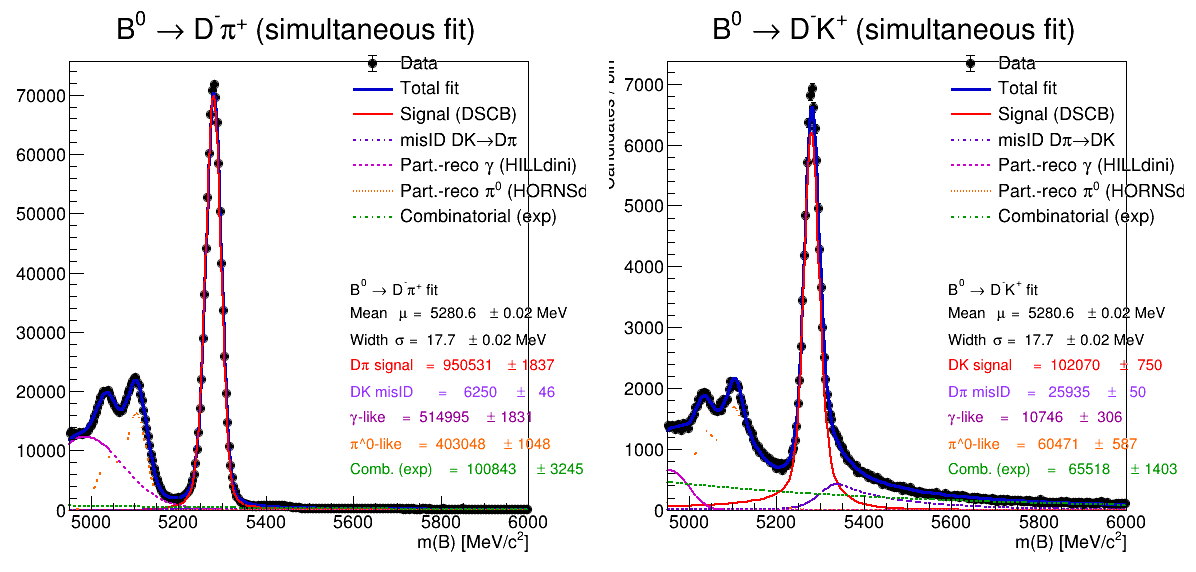



[70 RooFit INFO/Eval messages suppressed for readability]


Info in <TCanvas::Print>: png file /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png has been created



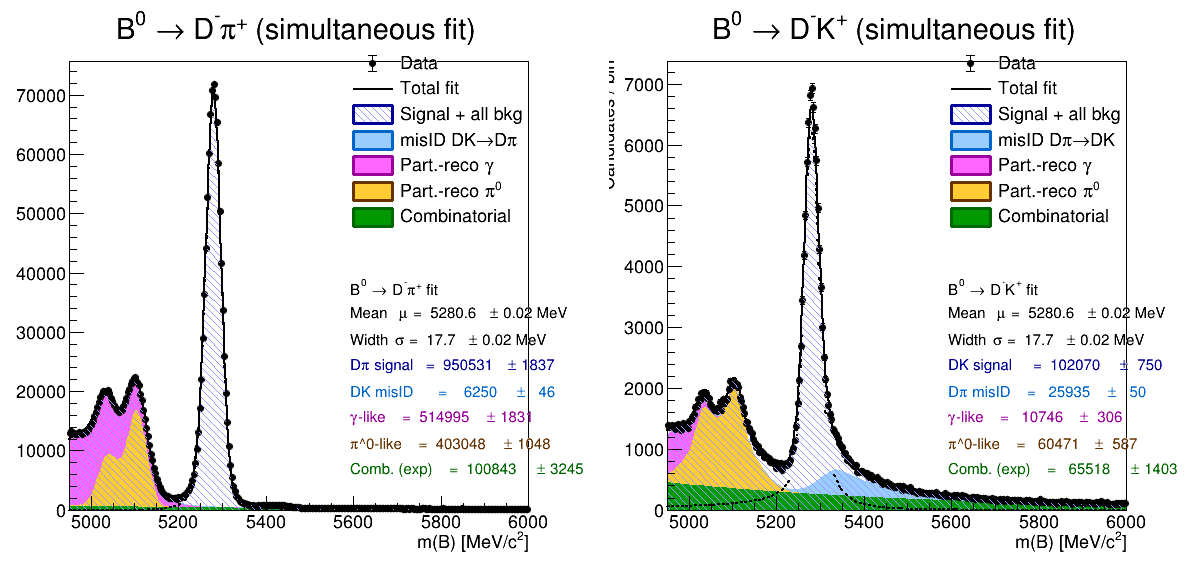

In [20]:
#  Plot simultaneous fit: Dπ and DK projections

# Dπ frame
frame_Dpi = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"))

# Data (Dπ slice) – give the plotted object an explicit name for the legend
combData.plotOn(
    frame_Dpi,
    RF.Cut("sample==sample::Dpi"),
    RF.Name("Dpi_data")
)

# Total PDF
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kBlue+1),
    RF.Name("Dpi_total")
)

# Signal component
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.Components("SIG_Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kRed),
    RF.LineWidth(2),
    RF.Name("Dpi_sig")
)

# mis-ID component (DK→Dπ)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.Components("MIS_Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kViolet+2),
    RF.LineStyle(kDashDotted),
    RF.LineWidth(2),
    RF.Name("Dpi_mis")
)

# HILL partial-reco
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.Components("BKG_g_Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kMagenta+1),
    RF.LineStyle(kDashed),
    RF.LineWidth(2),
    RF.Name("Dpi_hill")
)

# HORNS partial-reco
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.Components("BKG_pi_Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kOrange+7),
    RF.LineStyle(kDotted),
    RF.LineWidth(2),
    RF.Name("Dpi_horn")
)

# Combinatorial
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.Components("BKG_comb_Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kGreen+2),
    RF.LineStyle(kDashDotted),
    RF.LineWidth(2),
    RF.Name("Dpi_comb")
)

# DK frame
frame_DK = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"))

# Data (DK slice)
combData.plotOn(
    frame_DK,
    RF.Cut("sample==sample::DK"),
    RF.Name("DK_data")
)

# Total PDF
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kBlue+1),
    RF.Name("DK_total")
)

# Signal component
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.Components("SIG_DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kRed),
    RF.LineWidth(2),
    RF.Name("DK_sig")
)

# mis-ID component (Dπ→DK)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.Components("MIS_DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kViolet+2),
    RF.LineStyle(kDashDotted),
    RF.LineWidth(2),
    RF.Name("DK_mis")
)

# HILL partial-reco
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.Components("BKG_g_DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kMagenta+1),
    RF.LineStyle(kDashed),
    RF.LineWidth(2),
    RF.Name("DK_hill")
)

# HORNS partial-reco
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.Components("BKG_pi_DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kOrange+7),
    RF.LineStyle(kDotted),
    RF.LineWidth(2),
    RF.Name("DK_horn")
)

# Combinatorial
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.Components("BKG_comb_DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.LineColor(kGreen+2),
    RF.LineStyle(kDashDotted),
    RF.LineWidth(2),
    RF.Name("DK_comb")
)

#  Canvas, legends, yield boxes

c1 = ROOT.TCanvas("c1","Simultaneous Dπ/DK",1200,600)
c1.Divide(2,1)

# Left pad: Dπ
c1.cd(1)
frame_Dpi.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_Dpi.GetYaxis().SetTitle("Candidates / bin")
frame_Dpi.Draw()

leg1 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg1.SetFillStyle(0); leg1.SetBorderSize(0)
leg1.SetTextFont(42); leg1.SetTextSize(0.035)
leg1.AddEntry(frame_Dpi.findObject("Dpi_data"),   "Data", "pe")
leg1.AddEntry(frame_Dpi.findObject("Dpi_total"),  "Total fit", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_sig"),    "Signal (DSCB)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_mis"),    "misID DK#rightarrowD#pi", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_hill"),   "Part.-reco #gamma (HILLdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_horn"),   "Part.-reco #pi^{0} (HORNSdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_comb"),   "Combinatorial (exp)", "l")
leg1.Draw()

tab1 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab1.SetFillColor(0); tab1.SetFillStyle(0); tab1.SetBorderSize(0)
tab1.SetTextFont(42); tab1.SetTextSize(0.030); tab1.SetTextAlign(12)

line = tab1.AddText("B^{0} #rightarrow D^{-}#pi^{+} fit")
line.SetTextColor(kBlack)

line = tab1.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab1.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v,e = yields["Nsig_Dpi"]
line = tab1.AddText(f"D#pi signal   = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kRed)

v,e = yields["Nmis_Dpi"]
line = tab1.AddText(f"DK misID      = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kViolet+1)

v,e = yields["Ng_Dpi"]
line = tab1.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kMagenta+2)

v,e = yields["Npi_Dpi"]
line = tab1.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kOrange+7)

v,e = yields["Ncomb_Dpi"]
line = tab1.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kGreen+2)

tab1.Draw()

# Right pad: DK
c1.cd(2)
frame_DK.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_DK.GetYaxis().SetTitle("Candidates / bin")
frame_DK.Draw()

leg2 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg2.SetFillStyle(0); leg2.SetBorderSize(0)
leg2.SetTextFont(42); leg2.SetTextSize(0.035)
leg2.AddEntry(frame_DK.findObject("DK_data"),   "Data", "pe")
leg2.AddEntry(frame_DK.findObject("DK_total"),  "Total fit", "l")
leg2.AddEntry(frame_DK.findObject("DK_sig"),    "Signal (DSCB)", "l")
leg2.AddEntry(frame_DK.findObject("DK_mis"),    "misID D#pi#rightarrowDK", "l")
leg2.AddEntry(frame_DK.findObject("DK_hill"),   "Part.-reco #gamma (HILLdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_horn"),   "Part.-reco #pi^{0} (HORNSdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_comb"),   "Combinatorial (exp)", "l")
leg2.Draw()

tab2 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab2.SetFillColor(0); tab2.SetFillStyle(0); tab2.SetBorderSize(0)
tab2.SetTextFont(42); tab2.SetTextSize(0.030); tab2.SetTextAlign(12)

line = tab2.AddText("B^{0} #rightarrow D^{-}K^{+} fit")
line.SetTextColor(kBlack)

line = tab2.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab2.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v,e = yields["Nsig_DK"]
line = tab2.AddText(f"DK signal     = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kRed)

v,e = yields["Nmis_DK"]
line = tab2.AddText(f"D#pi misID    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kViolet+1)

v,e = yields["Ng_DK"]
line = tab2.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kMagenta+2)

v,e = yields["Npi_DK"]
line = tab2.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kOrange+7)

v,e = yields["Ncomb_DK"]
line = tab2.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kGreen+2)

tab2.Draw()

c1.Modified(); c1.Update()
ROOT.gSystem.ProcessEvents()

out_plot = "/tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png"
c1.SaveAs(out_plot)
print(f"Saved plot: {out_plot}")
ipydisplay(IPyImage(filename=out_plot))

Saved plot: /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png



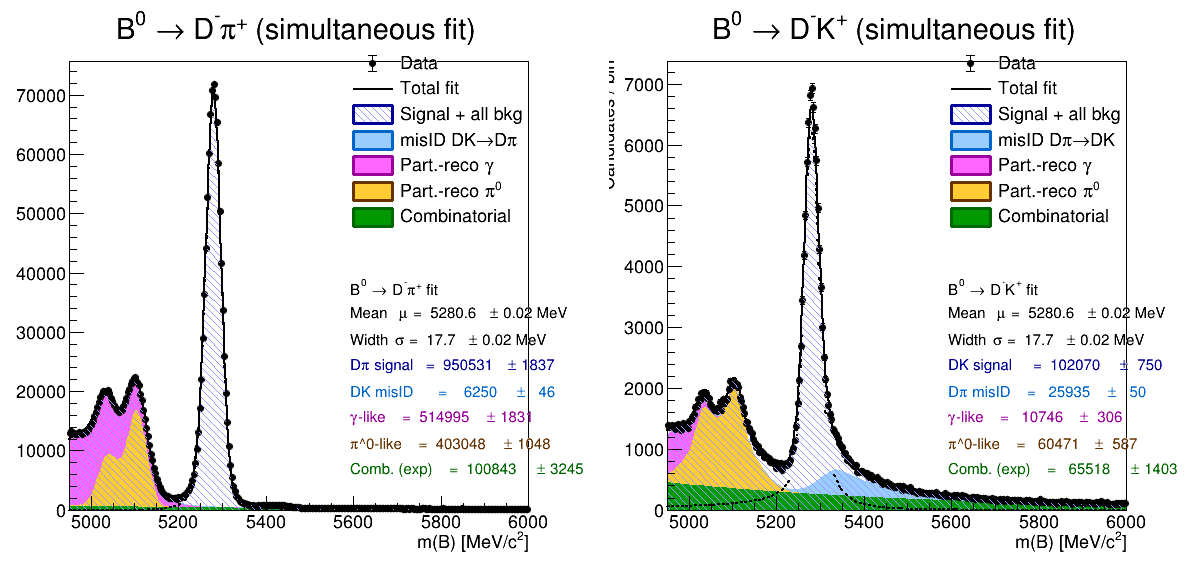



[82 RooFit INFO/Eval messages suppressed for readability]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png has been created



In [21]:
#  Stacked plots for the simultaneous fit (Dπ / DK)

# Dπ frame (stacked)
frame_Dpi = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"))

# Data: Dπ slice of combData
combData.plotOn(
    frame_Dpi,
    RF.Cut("sample==sample::Dpi"),
    RF.Name("Dpi_data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(kBlack)
)

# 1) combinatorial only (green, deepest layer)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi"),
    RF.Name("Dpi_comb_stack"),
    RF.FillColor(kGreen+2),
    RF.FillStyle(1001),
    RF.LineColor(kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 2) comb + pi0-like (orange)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi"),
    RF.Name("Dpi_pi0_stack"),
    RF.FillColor(kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 3) comb + pi0-like + gamma-like (magenta)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi"),
    RF.Name("Dpi_gamma_stack"),
    RF.FillColor(kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 4) comb + pi0-like + gamma-like + misID (light blue)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi,MIS_Dpi"),
    RF.Name("Dpi_mis_stack"),
    RF.FillColor(kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 5) Full model (signal + all backgrounds) – top region (dark blue hatch)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi,MIS_Dpi,SIG_Dpi"),
    RF.Name("Dpi_sig_stack"),
    RF.FillColor(kBlue-9),
    RF.FillStyle(3345),  # hatched
    RF.LineColor(kBlue+2),
    RF.DrawOption("F")
    # no MoveToBack here → stays on top
)

# Total model line on top of filled band
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Name("Dpi_total"),
    RF.LineColor(kBlack),
    RF.LineWidth(2)
)

# Optional signal-only dashed line
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("SIG_Dpi"),
    RF.Name("Dpi_sig_line"),
    RF.LineColor(kBlack),
    RF.LineStyle(kDashed),
    RF.LineWidth(2)
)

# DK frame (stacked)
frame_DK = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"))

combData.plotOn(
    frame_DK,
    RF.Cut("sample==sample::DK"),
    RF.Name("DK_data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(kBlack)
)

# 1) combinatorial (green)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK"),
    RF.Name("DK_comb_stack"),
    RF.FillColor(kGreen+2),
    RF.FillStyle(1001),
    RF.LineColor(kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 2) comb + pi0-like (orange)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK"),
    RF.Name("DK_pi0_stack"),
    RF.FillColor(kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 3) comb + pi0-like + gamma-like (magenta)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK"),
    RF.Name("DK_gamma_stack"),
    RF.FillColor(kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 4) comb + pi0-like + gamma-like + misID (light blue)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK,MIS_DK"),
    RF.Name("DK_mis_stack"),
    RF.FillColor(kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 5) full model (dark blue top)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK,MIS_DK,SIG_DK"),
    RF.Name("DK_sig_stack"),
    RF.FillColor(kBlue-9),
    RF.FillStyle(3345),
    RF.LineColor(kBlue+2),
    RF.DrawOption("F")
)

# total line
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Name("DK_total"),
    RF.LineColor(kBlack),
    RF.LineWidth(2)
)

# signal-only dashed
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("SIG_DK"),
    RF.Name("DK_sig_line"),
    RF.LineColor(kBlack),
    RF.LineStyle(kDashed),
    RF.LineWidth(2)
)

# Canvas + legends + yield tables
c1 = ROOT.TCanvas("c1","Simultaneous Dπ/DK stacked",1200,600)
c1.Divide(2,1)

# Left pad: Dπ
c1.cd(1)
frame_Dpi.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_Dpi.GetYaxis().SetTitle("Candidates / bin")
frame_Dpi.SetMinimum(0)
frame_Dpi.Draw()

leg1 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg1.SetFillStyle(0); leg1.SetBorderSize(0)
leg1.SetTextFont(42); leg1.SetTextSize(0.035)
leg1.AddEntry(frame_Dpi.findObject("Dpi_data"),       "Data",                    "pe")
leg1.AddEntry(frame_Dpi.findObject("Dpi_total"),      "Total fit",               "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_sig_stack"),  "Signal + all bkg",        "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_mis_stack"),  "misID DK#rightarrowD#pi", "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_gamma_stack"),"Part.-reco #gamma",       "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_pi0_stack"),  "Part.-reco #pi^{0}",      "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_comb_stack"), "Combinatorial",           "f")
leg1.Draw()

# Yield box for Dπ
tab1 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab1.SetFillColor(0); tab1.SetFillStyle(0); tab1.SetBorderSize(0)
tab1.SetTextFont(42); tab1.SetTextSize(0.030); tab1.SetTextAlign(12)

line = tab1.AddText("B^{0} #rightarrow D^{-}#pi^{+} fit"); line.SetTextColor(kBlack)
line = tab1.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV"); line.SetTextColor(kBlack)
line = tab1.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV"); line.SetTextColor(kBlack)

v,e = yields["Nsig_Dpi"];  line = tab1.AddText(f"D#pi signal   = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kBlue+2)
v,e = yields["Nmis_Dpi"];  line = tab1.AddText(f"DK misID      = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kAzure+2)
v,e = yields["Ng_Dpi"];    line = tab1.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kMagenta+2)
v,e = yields["Npi_Dpi"];   line = tab1.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kOrange+3)
v,e = yields["Ncomb_Dpi"]; line = tab1.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kGreen+3)
tab1.Draw()

# Right pad: DK
c1.cd(2)
frame_DK.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_DK.GetYaxis().SetTitle("Candidates / bin")
frame_DK.SetMinimum(0)
frame_DK.Draw()

leg2 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg2.SetFillStyle(0); leg2.SetBorderSize(0)
leg2.SetTextFont(42); leg2.SetTextSize(0.035)
leg2.AddEntry(frame_DK.findObject("DK_data"),       "Data",                    "pe")
leg2.AddEntry(frame_DK.findObject("DK_total"),      "Total fit",               "l")
leg2.AddEntry(frame_DK.findObject("DK_sig_stack"),  "Signal + all bkg",        "f")
leg2.AddEntry(frame_DK.findObject("DK_mis_stack"),  "misID D#pi#rightarrowDK", "f")
leg2.AddEntry(frame_DK.findObject("DK_gamma_stack"),"Part.-reco #gamma",       "f")
leg2.AddEntry(frame_DK.findObject("DK_pi0_stack"),  "Part.-reco #pi^{0}",      "f")
leg2.AddEntry(frame_DK.findObject("DK_comb_stack"), "Combinatorial",           "f")
leg2.Draw()

tab2 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab2.SetFillColor(0); tab2.SetFillStyle(0); tab2.SetBorderSize(0)
tab2.SetTextFont(42); tab2.SetTextSize(0.030); tab2.SetTextAlign(12)

line = tab2.AddText("B^{0} #rightarrow D^{-}K^{+} fit"); line.SetTextColor(kBlack)
line = tab2.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV"); line.SetTextColor(kBlack)
line = tab2.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV"); line.SetTextColor(kBlack)

v,e = yields["Nsig_DK"];  line = tab2.AddText(f"DK signal     = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kBlue+2)
v,e = yields["Nmis_DK"];  line = tab2.AddText(f"D#pi misID    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kAzure+2)
v,e = yields["Ng_DK"];    line = tab2.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kMagenta+2)
v,e = yields["Npi_DK"];   line = tab2.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kOrange+3)
v,e = yields["Ncomb_DK"]; line = tab2.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kGreen+3)
tab2.Draw()

c1.Modified(); c1.Update()
ROOT.gSystem.ProcessEvents()

out_plot = "/tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png"
c1.SaveAs(out_plot)
print(f"Saved plot: {out_plot}")
ipydisplay(IPyImage(filename=out_plot))